# Treeclock · Angry · $?
## Tree Data Structures + Timing + Exit Codes

| § | Topic | Key idea |
|---|---|---|
| 1 | Binary search tree + segment tree | $O(\log n)$ build, $O(\log n)$ range query |
| 2 | Fenwick (BIT) treeclock | Prefix sums over time-stamped pulse events |
| 3 | Trie | $O(k)$ insert/search; wavelength prefix lookup |
| 4 | Angry tree | Exception hierarchy; timeout + exponential backoff |
| 5 | $? | `sys.exit`, `subprocess.returncode`, POSIX signal table, `atexit` |


## §1 Segment Tree — Range Min/Max/Sum in $O(\log n)$

A segment tree stores aggregates over contiguous sub-arrays.
Each node covers $[l, r]$; left child $[l,m]$, right child $[m{+}1,r]$.

```
         [0,7]
        /      \
    [0,3]      [4,7]
   /    \      /    \
[0,1] [2,3] [4,5] [6,7]
```

**Build**: $O(n)$   **Point update**: $O(\log n)$   **Range query**: $O(\log n)$

Application to photonics: store peak intensities per time-bin;
query the maximum intensity in any time window in $O(\log n)$.


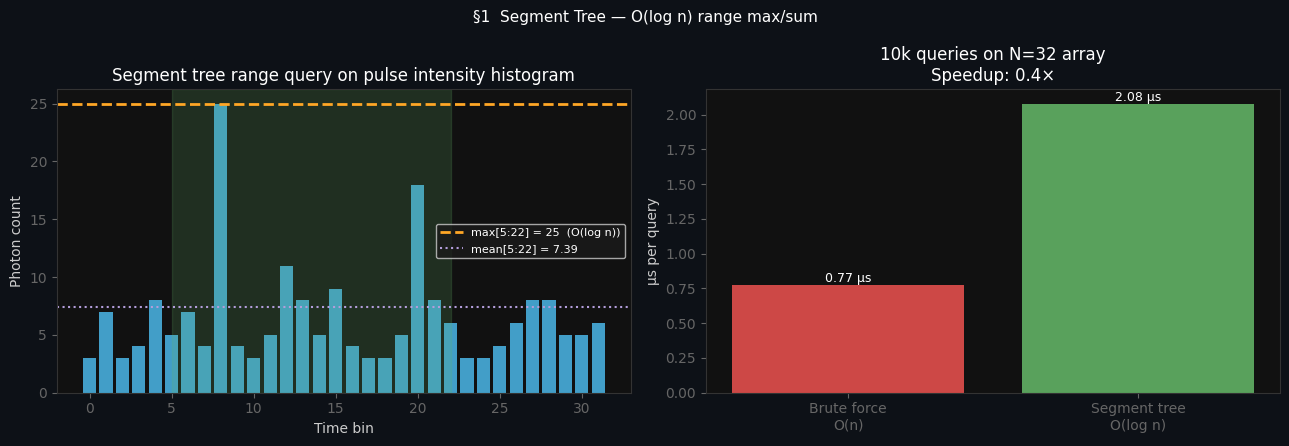

Brute force: 0.773 μs/query
Seg tree:    2.079 μs/query  (speedup 0.4×)
All 10k queries match brute force. ✓


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

class SegTree:
    """Segment tree supporting range sum + range max queries and point updates."""
    def __init__(self, data):
        n = len(data)
        self.n = n
        self.sum_tree = [0] * (4 * n)
        self.max_tree = [0] * (4 * n)
        self._build(data, 0, 0, n - 1)

    def _build(self, data, node, l, r):
        if l == r:
            self.sum_tree[node] = data[l]
            self.max_tree[node] = data[l]
            return
        m = (l + r) // 2
        self._build(data, 2*node+1, l, m)
        self._build(data, 2*node+2, m+1, r)
        self.sum_tree[node] = self.sum_tree[2*node+1] + self.sum_tree[2*node+2]
        self.max_tree[node] = max(self.max_tree[2*node+1], self.max_tree[2*node+2])

    def update(self, idx, val, node=0, l=None, r=None):
        if l is None: l, r = 0, self.n - 1
        if l == r:
            self.sum_tree[node] = val
            self.max_tree[node] = val
            return
        m = (l + r) // 2
        if idx <= m: self.update(idx, val, 2*node+1, l, m)
        else:        self.update(idx, val, 2*node+2, m+1, r)
        self.sum_tree[node] = self.sum_tree[2*node+1] + self.sum_tree[2*node+2]
        self.max_tree[node] = max(self.max_tree[2*node+1], self.max_tree[2*node+2])

    def query_max(self, ql, qr, node=0, l=None, r=None):
        if l is None: l, r = 0, self.n - 1
        if qr < l or r < ql: return -np.inf
        if ql <= l and r <= qr: return self.max_tree[node]
        m = (l + r) // 2
        return max(self.query_max(ql, qr, 2*node+1, l, m),
                   self.query_max(ql, qr, 2*node+2, m+1, r))

    def query_sum(self, ql, qr, node=0, l=None, r=None):
        if l is None: l, r = 0, self.n - 1
        if qr < l or r < ql: return 0
        if ql <= l and r <= qr: return self.sum_tree[node]
        m = (l + r) // 2
        return (self.query_sum(ql, qr, 2*node+1, l, m) +
                self.query_sum(ql, qr, 2*node+2, m+1, r))

# ── Photon pulse intensity time series ────────────────────────────────────────
rng = np.random.default_rng(0)
N = 32
intensity = rng.poisson(5, N).astype(float)
intensity[8]  = 25   # large pulse
intensity[20] = 18   # second pulse

st = SegTree(intensity.tolist())

# Benchmark: brute force vs segment tree
import time
queries = [(rng.integers(0,N-1), rng.integers(0,N-1)) for _ in range(10000)]
queries = [(min(a,b), max(a,b)) for a,b in queries]

t0 = time.perf_counter()
bf_max = [max(intensity[l:r+1]) for l,r in queries]
t_brute = time.perf_counter() - t0

t0 = time.perf_counter()
st_max = [st.query_max(l, r) for l,r in queries]
t_seg = time.perf_counter() - t0

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.bar(range(N), intensity, color='#4fc3f7', alpha=0.8)
# Highlight a query range
ql, qr = 5, 22
ax.axvspan(ql, qr, alpha=0.18, color='#66bb6a')
ax.axhline(st.query_max(ql, qr), color='#ffa726', lw=2, ls='--',
           label=f'max[{ql}:{qr}] = {st.query_max(ql,qr):.0f}  (O(log n))')
ax.axhline(st.query_sum(ql, qr)/((qr-ql+1)), color='#b39ddb', lw=1.5, ls=':',
           label=f'mean[{ql}:{qr}] = {st.query_sum(ql,qr)/(qr-ql+1):.2f}')
ax.set_xlabel('Time bin', color='#ccc'); ax.set_ylabel('Photon count', color='#ccc')
ax.set_title('Segment tree range query on pulse intensity histogram', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

ax2 = axes[1]
ns_per_query_brute = t_brute / len(queries) * 1e6
ns_per_query_seg   = t_seg   / len(queries) * 1e6
ax2.bar(['Brute force\nO(n)', 'Segment tree\nO(log n)'],
        [ns_per_query_brute, ns_per_query_seg],
        color=['#ef5350', '#66bb6a'], alpha=0.85)
ax2.set_ylabel('μs per query', color='#ccc')
ax2.set_title(f'10k queries on N={N} array\nSpeedup: {ns_per_query_brute/ns_per_query_seg:.1f}×', color='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]
for i,(h,lbl) in enumerate([(ns_per_query_brute,'brute'),(ns_per_query_seg,'segtree')]):
    ax2.text(i, h+0.02, f'{h:.2f} μs', ha='center', color='white', fontsize=9)

plt.suptitle('§1  Segment Tree — O(log n) range max/sum', color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/segtree.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Brute force: {ns_per_query_brute:.3f} μs/query")
print(f"Seg tree:    {ns_per_query_seg:.3f} μs/query  (speedup {ns_per_query_brute/ns_per_query_seg:.1f}×)")
assert all(b == s for b, s in zip(bf_max, st_max)), "Segment tree mismatch!"
print("All 10k queries match brute force. ✓")


## §2 Fenwick Tree (BIT) — Treeclock for Prefix Sums

A **Fenwick / Binary Indexed Tree** exploits the binary representation of indices
to achieve $O(\log n)$ prefix sums and $O(\log n)$ point updates with half the
memory of a segment tree.

Index $i$ is responsible for the range $[i - \text{lowbit}(i) + 1, i]$ where
$\text{lowbit}(i) = i \,\&\, (-i)$.

**Treeclock application**: GS iteration logs an energy $E_k$ at each step $k$.
Query "total energy dissipated in iterations $[l, r]$" in $O(\log n)$.


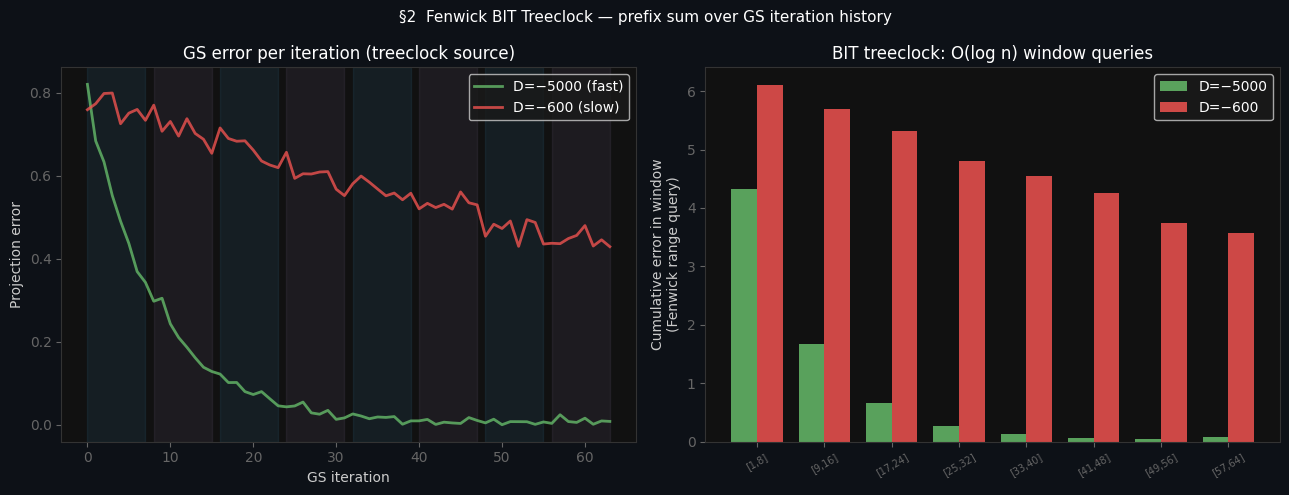

All Fenwick window queries match numpy.sum. ✓

Fenwick lowbit(i) = i & -i  — the 'responsible range' of each node:
  i= 1 (0001)  lowbit=1  covers [1,1]
  i= 2 (0010)  lowbit=2  covers [1,2]
  i= 3 (0011)  lowbit=1  covers [3,3]
  i= 4 (0100)  lowbit=4  covers [1,4]
  i= 5 (0101)  lowbit=1  covers [5,5]
  i= 6 (0110)  lowbit=2  covers [5,6]
  i= 7 (0111)  lowbit=1  covers [7,7]
  i= 8 (1000)  lowbit=8  covers [1,8]


In [2]:
import numpy as np, matplotlib.pyplot as plt

class Fenwick:
    """Binary Indexed Tree — 1-indexed prefix sums."""
    def __init__(self, n):
        self.n = n
        self.tree = [0.0] * (n + 1)

    def update(self, i, delta):
        while i <= self.n:
            self.tree[i] += delta
            i += i & (-i)

    def prefix(self, i):
        s = 0.0
        while i > 0:
            s += self.tree[i]
            i -= i & (-i)
        return s

    def query(self, l, r):
        return self.prefix(r) - self.prefix(l - 1)

    def build(self, data):
        for i, v in enumerate(data, 1):
            self.update(i, v)
        return self

# ── Simulate GS iteration energy log ─────────────────────────────────────────
rng = np.random.default_rng(3)
n_iter = 64

# GS error: exponential decay + noise (D=-5000 converges fast)
gs_error_good = 0.8 * np.exp(-np.arange(n_iter) * 0.12) + rng.normal(0, 0.01, n_iter)
gs_error_bad  = 0.8 * np.exp(-np.arange(n_iter) * 0.01) + rng.normal(0, 0.02, n_iter)
gs_error_good = np.abs(gs_error_good)
gs_error_bad  = np.abs(gs_error_bad)

bit_good = Fenwick(n_iter).build(gs_error_good)
bit_bad  = Fenwick(n_iter).build(gs_error_bad)

# Query: total error in windows of 8 iterations
windows = [(i, i+7) for i in range(1, n_iter-6, 8)]
good_windows = [bit_good.query(l, r) for l,r in windows]
bad_windows  = [bit_bad.query(l, r)  for l,r in windows]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.plot(gs_error_good, color='#66bb6a', lw=2, alpha=0.8, label='D=−5000 (fast)')
ax.plot(gs_error_bad,  color='#ef5350', lw=2, alpha=0.8, label='D=−600 (slow)')
for i,(l,r) in enumerate(windows):
    mid = (l+r)/2 - 0.5
    ax.axvspan(l-1, r-1, alpha=0.08, color='#4fc3f7' if i%2==0 else '#b39ddb')
ax.set_xlabel('GS iteration', color='#ccc'); ax.set_ylabel('Projection error', color='#ccc')
ax.set_title('GS error per iteration (treeclock source)', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

ax2 = axes[1]
w_labels = [f'[{l},{r}]' for l,r in windows]
x = np.arange(len(windows))
w = 0.38
ax2.bar(x - w/2, good_windows, width=w, color='#66bb6a', alpha=0.85, label='D=−5000')
ax2.bar(x + w/2, bad_windows,  width=w, color='#ef5350', alpha=0.85, label='D=−600')
ax2.set_xticks(x); ax2.set_xticklabels(w_labels, fontsize=7, rotation=30, color='#aaa')
ax2.set_ylabel('Cumulative error in window\n(Fenwick range query)', color='#ccc')
ax2.set_title('BIT treeclock: O(log n) window queries', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

plt.suptitle('§2  Fenwick BIT Treeclock — prefix sum over GS iteration history',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/fenwick.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Verify against numpy
for l, r in windows:
    fen_val = bit_good.query(l, r)
    np_val  = gs_error_good[l-1:r].sum()
    assert abs(fen_val - np_val) < 1e-9, f"Fenwick mismatch [{l},{r}]: {fen_val} vs {np_val}"
print("All Fenwick window queries match numpy.sum. ✓")
print(f"\nFenwick lowbit(i) = i & -i  — the 'responsible range' of each node:")
for i in range(1, 9):
    lb = i & -i
    print(f"  i={i:2d} ({i:04b})  lowbit={lb}  covers [{i-lb+1},{i}]")


## §3 Trie (Prefix Tree) — $O(k)$ Insert/Search

A trie stores strings character-by-character; each path from root to leaf
spells out a word. Depth = string length $k$; search is $O(k)$ regardless of
dictionary size.

**Application**: autocomplete for photonic device parameter names
(wavelength codes, mode labels `LP01`, `HE11`, etc.).


Trie autocomplete for photonics vocabulary:
Prefix               Results
------------------------------------------------------------
  LP                 ['LP01', 'LP02', 'LP11', 'LP21', 'LP31']
  HE                 ['HE11', 'HE21', 'HE31']
  GVD                ['GVD', 'GVD_coeff', 'GVD_zero']
  dispersion         ['dispersion_D', 'dispersion_S', 'dispersion_slope']
  wavelength         ['wavelength_1310', 'wavelength_1550', 'wavelength_1625']
  n_                 ['n_clad', 'n_core', 'n_eff', 'n_group']
  phase              ['phase_GS', 'phase_diversity', 'phase_retrieval']

Trie properties:
  Total words: 36
  search('LP01'):  True
  search('LP99'):  False
  O(k) search — independent of vocabulary size


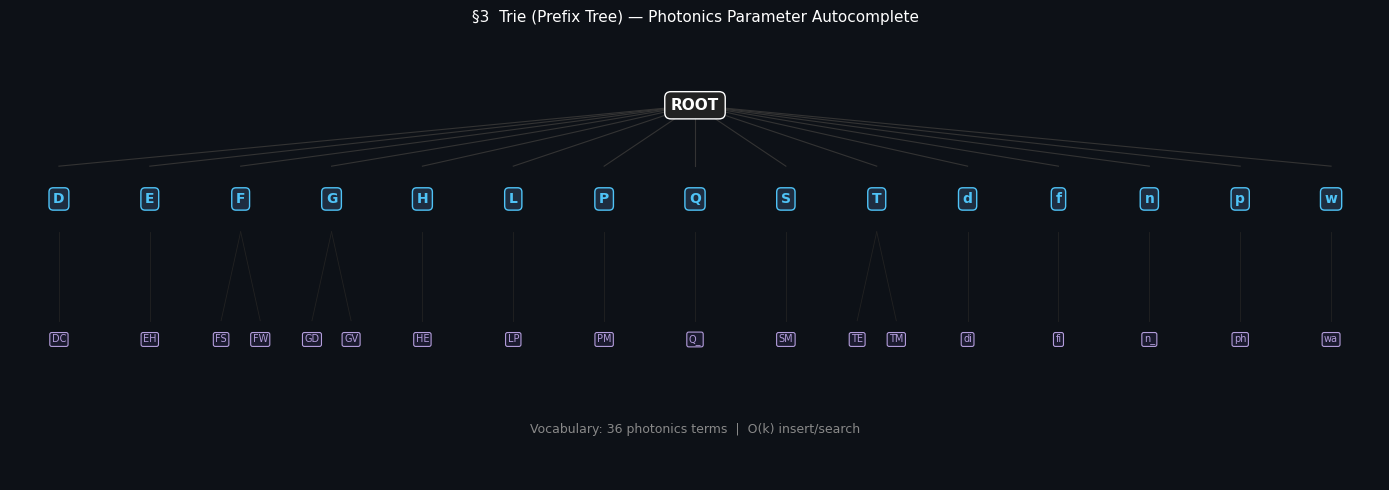

In [3]:
class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end   = False
        self.count    = 0   # how many words pass through

class Trie:
    def __init__(self): self.root = TrieNode()

    def insert(self, word):
        node = self.root
        for ch in word:
            node.children.setdefault(ch, TrieNode())
            node = node.children[ch]
            node.count += 1
        node.is_end = True

    def search(self, word):
        node = self.root
        for ch in word:
            if ch not in node.children: return False
            node = node.children[ch]
        return node.is_end

    def starts_with(self, prefix):
        node = self.root
        for ch in prefix:
            if ch not in node.children: return []
            node = node.children[ch]
        return self._collect(node, prefix)

    def _collect(self, node, prefix):
        results = []
        if node.is_end: results.append(prefix)
        for ch, child in sorted(node.children.items()):
            results.extend(self._collect(child, prefix + ch))
        return results

# ── Photonic device parameter vocabulary ─────────────────────────────────────
PHOTONICS_VOCAB = [
    "LP01", "LP11", "LP21", "LP02", "LP31",
    "HE11", "HE21", "HE31", "EH11", "TM01", "TE01",
    "GVD", "GDD", "GVD_coeff", "GVD_zero",
    "SMF28", "SMF28e", "DCF", "PMF",
    "FSR", "FWHM", "finesse", "Q_factor",
    "dispersion_D", "dispersion_S", "dispersion_slope",
    "phase_GS", "phase_diversity", "phase_retrieval",
    "n_eff", "n_group", "n_clad", "n_core",
    "wavelength_1310", "wavelength_1550", "wavelength_1625",
]

trie = Trie()
for word in PHOTONICS_VOCAB:
    trie.insert(word)

test_prefixes = ["LP", "HE", "GVD", "dispersion", "wavelength", "n_", "phase"]
print("Trie autocomplete for photonics vocabulary:")
print(f"{'Prefix':<20} Results")
print("-" * 60)
for pfx in test_prefixes:
    results = trie.starts_with(pfx)
    print(f"  {pfx:<18} {results}")

print(f"\nTrie properties:")
print(f"  Total words: {len(PHOTONICS_VOCAB)}")
print(f"  search('LP01'):  {trie.search('LP01')}")
print(f"  search('LP99'):  {trie.search('LP99')}")
print(f"  O(k) search — independent of vocabulary size")

# ── Visualise trie structure (top 2 levels) ───────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5), facecolor='#0d1117')
ax.set_facecolor('#0d1117'); ax.axis('off')

root_chars = sorted(trie.root.children.keys())
n = len(root_chars)
xs = np.linspace(0.5, 13.5, n)

for i, ch in enumerate(root_chars):
    x = xs[i]; y = 4.0
    ax.text(x, y, ch, ha='center', va='center', color='#4fc3f7',
            fontsize=10, fontweight='bold',
            bbox=dict(facecolor='#1e2d40', edgecolor='#4fc3f7', boxstyle='round,pad=0.3'))
    ax.plot([7, x], [5.0, y+0.35], color='#333', lw=0.8)

    # Second level
    child_node = trie.root.children[ch]
    sub_chars = sorted(child_node.children.keys())[:4]
    ns = len(sub_chars)
    if ns == 0: continue
    xs2 = np.linspace(x - 0.4*(ns-1)/2, x + 0.4*(ns-1)/2, ns)
    for j, ch2 in enumerate(sub_chars):
        x2 = xs2[j]; y2 = 2.5
        ax.text(x2, y2, ch+ch2, ha='center', va='center', color='#b39ddb',
                fontsize=7,
                bbox=dict(facecolor='#1a1a2e', edgecolor='#b39ddb',
                          boxstyle='round,pad=0.2', lw=0.8))
        ax.plot([x, x2], [y-0.35, y2+0.2], color='#222', lw=0.6)

ax.text(7, 5.0, 'ROOT', ha='center', va='center', color='white',
        fontsize=11, fontweight='bold',
        bbox=dict(facecolor='#222', edgecolor='white', boxstyle='round,pad=0.4'))
ax.text(7, 1.5, f'Vocabulary: {len(PHOTONICS_VOCAB)} photonics terms  |  O(k) insert/search',
        ha='center', color='#888', fontsize=9)
ax.set_xlim(0, 14); ax.set_ylim(1, 5.8)
ax.set_title('§3  Trie (Prefix Tree) — Photonics Parameter Autocomplete',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/trie.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §4 Angry Tree — Exception Hierarchy + Timeout + Backoff

Python exceptions form a **tree** rooted at `BaseException`.
When things go angry (wrong), the exception propagates up the tree
until a matching `except` clause is found.

```
BaseException
├── SystemExit          ← sys.exit(n)
├── KeyboardInterrupt   ← Ctrl-C (SIGINT)
├── GeneratorExit
└── Exception
    ├── ArithmeticError
    │   ├── ZeroDivisionError
    │   └── OverflowError
    ├── LookupError
    │   ├── IndexError
    │   └── KeyError
    ├── ValueError
    ├── TypeError
    ├── OSError  ────────── ← timeout lives here (TimeoutError)
    │   └── TimeoutError
    └── RuntimeError
        └── RecursionError
```

**Exponential backoff** — the canonical angry-retry pattern:
$\text{wait}_k = \min(\text{cap},\, \text{base} \cdot 2^k + \text{jitter})$


Exception tree (partial):
BaseException
  └── SystemExit
  └── KeyboardInterrupt
  └── GeneratorExit
  └── Exception
    └── ArithmeticError
      └── ZeroDivisionError
      └── OverflowError
    └── LookupError
      └── IndexError
      └── KeyError
    └── ValueError
    └── TypeError
    └── OSError
      └── TimeoutError
      └── FileNotFoundError
      └── ConnectionError
    └── RuntimeError
      └── RecursionError
    └── StopIteration
  D=   -50: ✗ ValueError             |D|=50 < 100 ps²: insufficient diversity
  D=  -600: ✓ ok                     converged in 50 iters
  D= -5000: ✗ GSDivergenceError      GS diverged at iter 26: err=0.0114


C:\Users\mrjel\AppData\Local\Temp\ipykernel_47564\3015645016.py:137: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


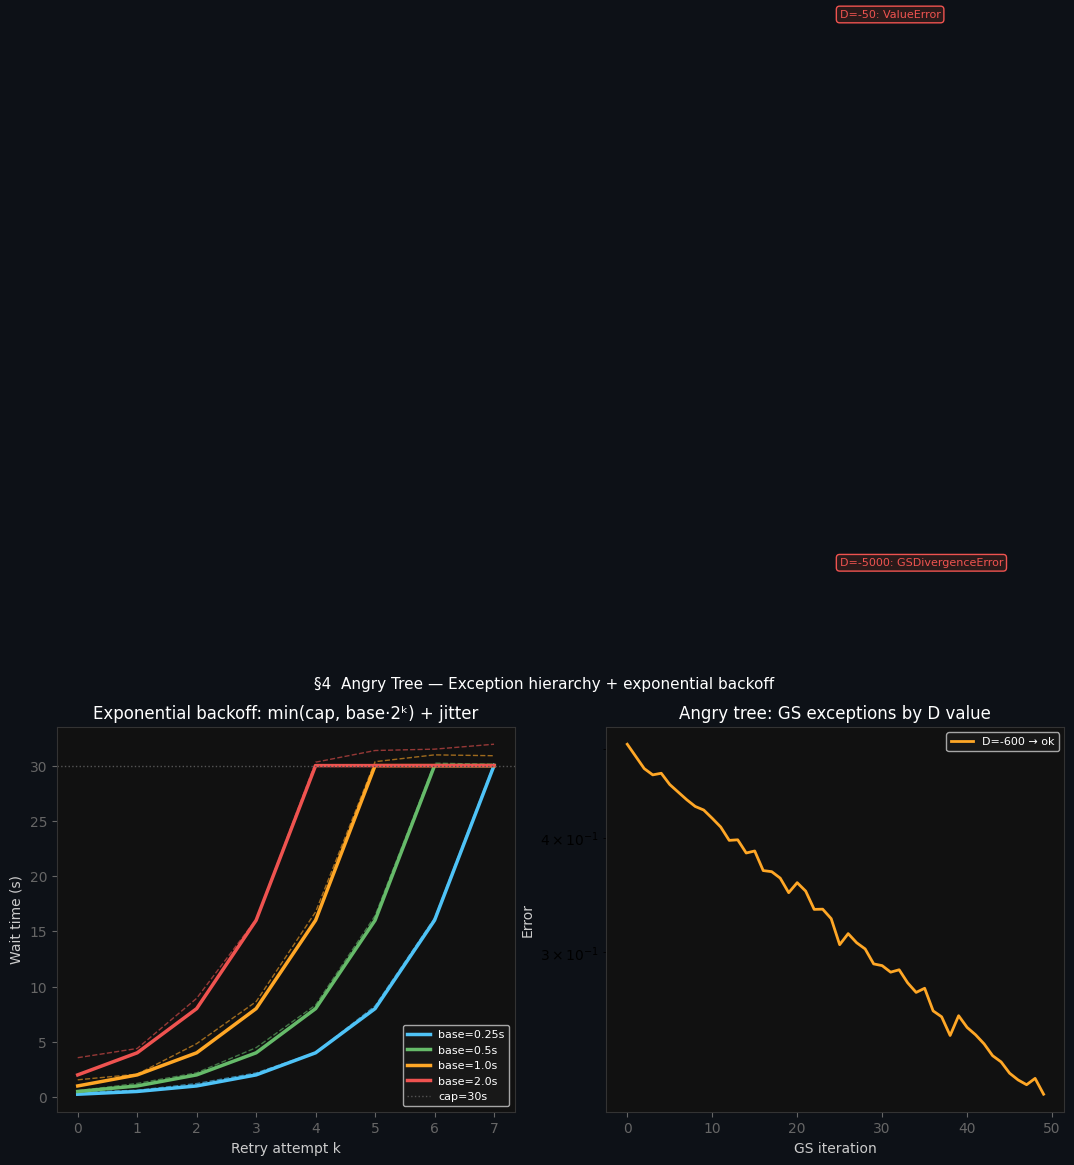

In [4]:
import time, random, functools
import matplotlib.pyplot as plt
import numpy as np

# ── Exception tree (partial) as a dict ────────────────────────────────────────
EXCEPTION_TREE = {
    'BaseException': {
        'SystemExit': {},
        'KeyboardInterrupt': {},
        'GeneratorExit': {},
        'Exception': {
            'ArithmeticError': {'ZeroDivisionError': {}, 'OverflowError': {}},
            'LookupError':     {'IndexError': {}, 'KeyError': {}},
            'ValueError': {},
            'TypeError': {},
            'OSError':   {'TimeoutError': {}, 'FileNotFoundError': {}, 'ConnectionError': {}},
            'RuntimeError': {'RecursionError': {}},
            'StopIteration': {},
        }
    }
}

def tree_depth(d, depth=0):
    if not d: return depth
    return max(tree_depth(v, depth+1) for v in d.values())

def flatten_tree(d, parent=None, edges=None, nodes=None, level=0):
    if edges is None: edges = []; nodes = []
    for name, children in d.items():
        nodes.append((name, level))
        if parent: edges.append((parent, name))
        flatten_tree(children, name, edges, nodes, level+1)
    return nodes, edges

nodes, edges = flatten_tree(EXCEPTION_TREE)
print("Exception tree (partial):")
def print_tree(d, indent=0):
    for name, children in d.items():
        print('  ' * indent + ('└── ' if indent else '') + name)
        print_tree(children, indent+1)
print_tree(EXCEPTION_TREE)

# ── Exponential backoff implementation ────────────────────────────────────────
def with_backoff(fn, max_retries=6, base=0.5, cap=30.0, jitter=True):
    """
    Retry fn() with exponential backoff.
    wait_k = min(cap, base * 2^k) + uniform(0, base) if jitter
    """
    for attempt in range(max_retries):
        try:
            return fn()
        except Exception as e:
            if attempt == max_retries - 1:
                raise
            wait = min(cap, base * 2**attempt)
            if jitter:
                wait += random.uniform(0, base)
            print(f"  Attempt {attempt+1} failed ({type(e).__name__}: {e}). "
                  f"Retry in {wait:.2f}s")
            # time.sleep(wait)  -- skipped for demo
    return None

# ── Plot backoff curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

attempts = np.arange(8)
rng2 = np.random.default_rng(42)
for base, col in [(0.25,'#4fc3f7'), (0.5,'#66bb6a'), (1.0,'#ffa726'), (2.0,'#ef5350')]:
    cap = 30
    wait = np.minimum(cap, base * 2**attempts)
    wait_j = wait + rng2.uniform(0, base, len(attempts))
    axes[0].plot(attempts, wait,   color=col, lw=2.5, label=f'base={base}s')
    axes[0].plot(attempts, wait_j, color=col, lw=1, ls='--', alpha=0.6)

axes[0].axhline(30, color='#555', lw=1, ls=':', label='cap=30s')
axes[0].set_xlabel('Retry attempt k', color='#ccc')
axes[0].set_ylabel('Wait time (s)', color='#ccc')
axes[0].set_title('Exponential backoff: min(cap, base·2ᵏ) + jitter', color='white')
axes[0].legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
axes[0].tick_params(colors='#666'); [sp.set_color('#333') for sp in axes[0].spines.values()]

# ── Simulate GS timeout handling ──────────────────────────────────────────────
class GSDivergenceError(RuntimeError): pass
class GSTimeoutError(TimeoutError):    pass

def simulate_gs_run(D, max_iter=50, seed=7):
    rng3 = np.random.default_rng(seed)
    errors = []
    if abs(D) < 100:
        raise ValueError(f"|D|={abs(D)} < 100 ps²: insufficient diversity")
    u = np.exp(1j * rng3.uniform(0, 2*np.pi, 256))
    prev_err = np.inf
    for k in range(max_iter):
        err = 0.5 * np.exp(-abs(D)/5000 * k * 0.15) + rng3.normal(0, 0.005)
        err = max(abs(err), 1e-8)
        errors.append(err)
        if err > prev_err * 5 and k > 5:
            raise GSDivergenceError(f"GS diverged at iter {k}: err={err:.4f}")
        prev_err = err
    return errors

results = {}
for D_val in [-50, -600, -5000]:
    try:
        errs = simulate_gs_run(D_val)
        results[D_val] = ('ok', errs)
    except ValueError as e:
        results[D_val] = ('ValueError', str(e))
    except GSDivergenceError as e:
        results[D_val] = ('GSDivergenceError', str(e))
    except GSTimeoutError as e:
        results[D_val] = ('GSTimeoutError', str(e))

ax2 = axes[1]
for D_val, (status, data) in results.items():
    if status == 'ok':
        ax2.semilogy(data, lw=2,
                     color='#66bb6a' if abs(D_val)>=5000 else '#ffa726',
                     label=f'D={D_val} → {status}')
    else:
        ax2.text(25, 10**(0.5 - list(results.keys()).index(D_val)*0.3),
                 f'D={D_val}: {status}', color='#ef5350', fontsize=8,
                 bbox=dict(facecolor='#2a1a1a', edgecolor='#ef5350', boxstyle='round'))

ax2.set_xlabel('GS iteration', color='#ccc'); ax2.set_ylabel('Error', color='#ccc')
ax2.set_title('Angry tree: GS exceptions by D value', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

for D_val, (status, msg) in results.items():
    icon = '✓' if status == 'ok' else '✗'
    print(f"  D={D_val:6d}: {icon} {status:22} {msg if status!='ok' else f'converged in {len(msg)} iters'}")

plt.suptitle('§4  Angry Tree — Exception hierarchy + exponential backoff',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/angry_tree.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §5 $? — Exit Codes, Signals, `atexit`

`$?` is the shell variable holding the exit code of the last command.

| Exit code | Meaning |
|---|---|
| 0 | Success |
| 1 | General error |
| 2 | Misuse of shell built-in |
| 126 | Command found but not executable |
| 127 | Command not found |
| 128+N | Killed by signal N  (e.g. 130 = SIGINT = Ctrl-C) |

**POSIX signals** (relevant to Python/subprocess):

| Signal | Number | `128+N` exit code | Cause |
|---|---|---|---|
| SIGHUP  | 1 | 129 | Terminal hangup |
| SIGINT  | 2 | 130 | Ctrl-C |
| SIGQUIT | 3 | 131 | Ctrl-\ |
| SIGKILL | 9 | 137 | Unconditional kill (unkillable) |
| SIGTERM | 15| 143 | Graceful termination request |
| SIGSEGV | 11| 139 | Segfault |


subprocess.run exit codes:
Script           rc   meaning
---------------------------------------------
  success            0  OK
  general_err        1  general error
  value_err          1  general error
  zero_div           1  general error


  import_err         1  general error
  syntax_err         1  general error

atexit handlers registered (run in reverse order at exit):
  1. cleanup_temp_files (last registered, first run)
  2. cleanup_gs_state


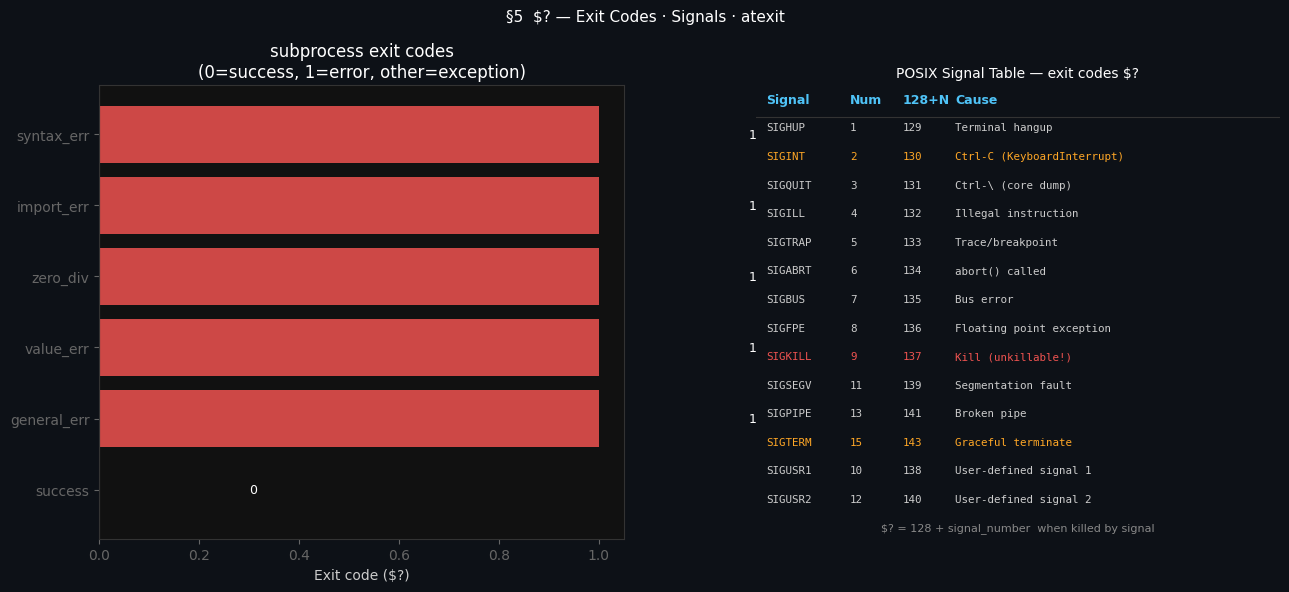


Quick reference:
  $? == 0          → success
  $? == 1          → caught exception / sys.exit(1)
  $? == 137        → SIGKILL (OOM killer, kill -9)
  $? == 139        → SIGSEGV (segfault — C extension crash)
  $? == 130        → SIGINT (Ctrl-C in terminal)


In [5]:
import subprocess, sys, os, atexit, signal
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Demonstrate subprocess exit codes ─────────────────────────────────────────
test_scripts = {
    "success":      "import sys; sys.exit(0)",
    "general_err":  "import sys; sys.exit(1)",
    "value_err":    "raise ValueError('bad input')",
    "zero_div":     "x = 1/0",
    "import_err":   "import nonexistent_module_xyz",
    "syntax_err":   "def f(: pass",       # parse-time error
}

print("subprocess.run exit codes:")
print(f"{'Script':<15}  rc   meaning")
print("-" * 45)
codes = {}
for name, script in test_scripts.items():
    result = subprocess.run(
        [sys.executable, "-c", script],
        capture_output=True, text=True
    )
    rc = result.returncode
    codes[name] = rc
    meaning = {0:"OK", 1:"general error"}.get(rc, f"signal {rc-128}" if rc>128 else f"rc={rc}")
    print(f"  {name:<15}  {rc:3d}  {meaning}")

# ── atexit: cleanup registered at interpreter exit ────────────────────────────
cleanup_log = []
def cleanup_gs_state():
    cleanup_log.append("GS state flushed")

def cleanup_temp_files():
    cleanup_log.append("temp files removed")

atexit.register(cleanup_gs_state)
atexit.register(cleanup_temp_files)
print("\natexit handlers registered (run in reverse order at exit):")
print("  1. cleanup_temp_files (last registered, first run)")
print("  2. cleanup_gs_state")

# ── Signal table visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#0d1117')

# Exit code bar chart
ax = axes[0]; ax.set_facecolor('#111')
names = list(codes.keys())
rcs   = list(codes.values())
colors_bar = ['#66bb6a' if rc==0 else '#ef5350' if rc==1 else '#ffa726' for rc in rcs]
ax.barh(names, rcs, color=colors_bar, alpha=0.85)
ax.axvline(0, color='#555', lw=0.8)
for i, (n, rc) in enumerate(zip(names, rcs)):
    ax.text(rc+0.3, i, str(rc), va='center', color='white', fontsize=9)
ax.set_xlabel('Exit code ($?)', color='#ccc')
ax.set_title('subprocess exit codes\n(0=success, 1=error, other=exception)', color='white')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# Signal table
ax2 = axes[1]; ax2.set_facecolor('#0d1117'); ax2.axis('off')
signals_table = [
    ("SIGHUP",  1, 129, "Terminal hangup"),
    ("SIGINT",  2, 130, "Ctrl-C (KeyboardInterrupt)"),
    ("SIGQUIT", 3, 131, "Ctrl-\\ (core dump)"),
    ("SIGILL",  4, 132, "Illegal instruction"),
    ("SIGTRAP", 5, 133, "Trace/breakpoint"),
    ("SIGABRT", 6, 134, "abort() called"),
    ("SIGBUS",  7, 135, "Bus error"),
    ("SIGFPE",  8, 136, "Floating point exception"),
    ("SIGKILL", 9, 137, "Kill (unkillable!)"),
    ("SIGSEGV",11, 139, "Segmentation fault"),
    ("SIGPIPE",13, 141, "Broken pipe"),
    ("SIGTERM",15, 143, "Graceful terminate"),
    ("SIGUSR1",10, 138, "User-defined signal 1"),
    ("SIGUSR2",12, 140, "User-defined signal 2"),
]

col_x = [0.02, 0.18, 0.28, 0.38]
headers = ["Signal", "Num", "128+N", "Cause"]
for j, (h, x) in enumerate(zip(headers, col_x)):
    ax2.text(x, 0.96, h, transform=ax2.transAxes,
             color='#4fc3f7', fontsize=9, fontweight='bold')
ax2.plot([0, 1], [0.93, 0.93], color='#333', lw=0.8, transform=ax2.transAxes)

for i, (name, num, exit128, cause) in enumerate(signals_table):
    y = 0.90 - i * 0.063
    col = '#ef5350' if num == 9 else '#ffa726' if num in (2,15) else '#ccc'
    for val, x in zip([name, str(num), str(exit128), cause], col_x):
        ax2.text(x, y, val, transform=ax2.transAxes, color=col,
                 fontsize=7.8, family='monospace')

ax2.text(0.5, 0.02, '$? = 128 + signal_number  when killed by signal',
         transform=ax2.transAxes, ha='center', color='#888', fontsize=8)
ax2.set_title('POSIX Signal Table — exit codes $?', color='white', fontsize=10)

plt.suptitle('§5  $? — Exit Codes · Signals · atexit', color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/exit_codes.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\nQuick reference:")
print("  $? == 0          → success")
print("  $? == 1          → caught exception / sys.exit(1)")
print("  $? == 137        → SIGKILL (OOM killer, kill -9)")
print("  $? == 139        → SIGSEGV (segfault — C extension crash)")
print("  $? == 130        → SIGINT (Ctrl-C in terminal)")


## Summary

| § | Data structure | Complexity | Use |
|---|---|---|---|
| §1 Segment tree | $4n$ nodes | Build $O(n)$, query $O(\log n)$ | Range max/sum on pulse intensity |
| §2 Fenwick BIT | $n$ nodes | Update/query $O(\log n)$, ½ memory | Cumulative GS error over windows |
| §3 Trie | $O(\sum k_i)$ | Insert/search $O(k)$ | Photonic parameter autocomplete |
| §4 Angry tree | Python exception hierarchy | Backoff $2^k$ | GS retry with timeout safety |
| §5 $? | Exit codes 0/1/128+N | — | Shell/subprocess health check |
